# Grid 4×4 — Hub-centric OD demand + realism capstone (seed 42)

This notebook reports the **OD-hub** experiment batch (gpujobs, libsumo, seed 42): a
**demand realism** protocol composed with optional **`realism_full`** plant/sensor stress.

**Results sections below** follow the same table + 3-panel learning-curve style as
[`realism_benchmark_4x4.ipynb`](realism_benchmark_4x4.ipynb).

**Do not** compare ATT here to legacy **3600 s** single-movie LibSignal Table-8 runs.


## 1. What we are testing (research claim)

Open RL-TSC benchmarks often optimize on **one fixed `.rou.xml` every episode**. That
can reward **memorizing a traffic movie** rather than controlling under varying demand.

We already built **world/sensor realism** (hetero, slow-start, crossing proxy, partial
observability, and their `realism_full` composition). This batch adds **demand realism**:

| Layer | Question |
|-------|----------|
| **Demand** | Do methods generalize when OD, departures, and peak timing **change across episodes**? |
| **Held-out eval** | Is performance on **unseen** `hold_*` files honest (not the training movie)? |
| **L2** | Under **compound** demand + plant/sensor stress, does **MaxPressure** remain the anchor? |

**Primary metric:** `HELDOUT_MEAN` — mean vehicle ATT (s) over `hold_00`, `hold_01`, `hold_02`
(lower is better). Ground-truth physics ATT; partial obs affects what RL *sees*, not the metric.

Further demand statistics: [`od_hub_demand_distribution.md`](od_hub_demand_distribution.md).
Protocol & configs: [`docs/OD_HUB_DEMAND.md`](../docs/OD_HUB_DEMAND.md).


## 1a. What is **new** vs default LibSignal? (highlight)

> **Default grid4×4 LibSignal:** one **fixed** route movie every episode — same OD pairs, same departure times. RL can overfit that file; there is no hub-centric OD model and no held-out demand eval.

> **This work stacks realism layers.** Earlier axis studies (homo → slow-start → hetero → partial obs → crossing → `realism_full`) stressed **plant & sensors**. **OD-hub** adds a **demand** layer on top. **Level 2** turns **all** of that on at once.

| | Default / single-movie | **OD-hub (this batch)** |
|---|------------------------|-------------------------|
| **OD pairs** | Frozen in one `.rou.xml` | **Resampled** per file (gravity + hubs) |
| **Hub structure** | Incidental | **Explicit** (~88% hub dest, ~95% routes touch hub) |
| **Origins** | Whatever the movie has | **~65% fringe / ~35% within-network** |
| **Departure time** | Fixed in file | **Peak + shoulder** timeline; random in-bin |
| **Episode demand** | Identical | **Rotate `train_*`**; score on **unseen `hold_*`** |
| **Travel times** | SUMO outcome on that movie | SUMO outcome on **varying** demand (not a separate random ATT model) |
| **L1 world** | Often homo baseline | Homo (isolates **demand** realism) |
| **L2 world** | N/A in one run | Same demand + **`realism_full`** (hetero, slow-start, crossing, partial obs) |

**Takeaway:** randomness and structure here are in **who goes where, when, and which file you see** — not in bypassing SUMO physics. That is realism the default **one-movie** protocol did not enforce.


### Realism stack (how this fits the program)

```mermaid
flowchart BT
  subgraph demand [NEW — demand realism OD-hub]
    OD["Hub OD + peak timeline\n10 train / 3 hold files"]
  end
  subgraph plant [Plant — realism_full L2]
    H["Hetero 80/20"]
    SS["Slow-start vTypes"]
    CP["Crossing proxy p=0.12"]
  end
  subgraph sensor [Sensor — realism_full L2]
    P["80% obs penetration"]
    N["Gaussian count noise σ=2"]
  end
  demand --> plant
  plant --> sensor
  sensor --> CTRL["Controllers\nMP FT DQN PL CL"]
```

- **Axis notebooks** (`realism_benchmark_4x4.ipynb`): one axis (or capstone) at a time, **fixed** demand movie.
- **This notebook:** **honest demand generalization** first (L1), then **same demand + full plant/sensor** (L2).


## 2. Demand realism — protocol & diagram

**Generator:** `extras/gen_od_hub_demand_grid4x4.py` → `data/raw_data/grid4x4/od_hubs/demand_set/`

| Role | Files | Used for |
|------|-------|----------|
| Train rotation | `train_00` … `train_09` (10) | RL episode `e` loads `train[e mod 10]` |
| Held-out eval | `hold_00` … `hold_02` (3) | Greedy eval only → `HELDOUT` / `HELDOUT_MEAN` |
| Fixed (optional) | `fixed_1800` | Not used when `demand_set` is set in YAML |

- **Horizon:** 1800 s sim steps per episode (~800 vehicles per file).
- **Routing:** `duarouter` shortest path on corrected `grid4x4.net.xml`.
- **RL:** 100 episodes; held-out every 10 (`configs/tsc/od_hub_1800_base.yml`).
- **Baselines:** 1 episode, held-out only (`episodes: 1` in `*_odh_l1/l2` agent YAML).

```mermaid
flowchart LR
  Gen["OD generator\nTAZ + gravity OD"] --> Set["Demand set\n14 × .rou.xml"]
  Set --> L1["Level 1\nOD-hub only"]
  Set --> L2["Level 2\nOD-hub + realism_full"]
  L1 --> Score["HELDOUT_MEAN tables"]
  L2 --> Score
```

```mermaid
flowchart TB
  subgraph train_loop [Training episode e]
    TR["train_k.rou.xml"] --> Sim["SUMO 1800s"]
    Sim --> RL["RL update\n(DQN / PressLight / CoLight)"]
  end
  subgraph eval_loop [Every 10 episodes]
    H0["hold_00"] --> HO["Greedy rollout"]
    H1["hold_01"] --> HO
    H2["hold_02"] --> HO
    HO --> HM["HELDOUT_MEAN ATT"]
  end
  RL -.-> eval_loop
```


## 3. Demand realism — components & realized distributions

Synthetic **hub-centric** OD (not city LODES import). Hubs are **inherent** to the demand
model (majority of trips touch hub approaches).

### Composition (14 files, validated)

| Component | Design target | Realized (mean over files) |
|-----------|---------------|----------------------------|
| Fringe origins | ~60–70% | **65.1%** |
| Within-network origins | ~30–40% | **34.9%** |
| Hub as destination | ~70% knob + gravity | **~88%** end at hub edges |
| Hub-touch (route uses hub edge) | majority | **~95%** |
| Vehicles per file | ~800 | **794 ± 26** (Gaussian draw per file) |
| Train vs hold | stochastic disjoint seeds | distinct OD & depart times |

### Peak timeline (shoulder + peak, 300 s bins)

Weights → `od2trips` random departures **inside each bin** (not uniform spread; not Poisson end-to-end).

| Bin (s) | Share of departures |
|---------|--------------------:|
| 0–300 | 8% |
| 300–600 | 12% |
| 600–900 | 22% |
| **900–1200 (peak)** | **28%** |
| 1200–1500 | 18% |
| 1500–1800 | 12% |

Pooled realized shares match design within **~0.1%**. Within-bin gaps are **random** (peak bin CV ≈ 0.93 vs 1.0 for Poisson).

### Stochasticity

- Each `train_*` / `hold_*` file = new OD sample + timeline split + random in-bin departures.
- **Generalization test:** train on `train_*`, score on **never-seen** `hold_*`.


## 4. Experiment levels (this notebook)

| Level | Config suffix | World | Same demand set? |
|-------|---------------|--------|------------------|
| **L1** | `*_odh_l1`, prefix `odh_l1` | Homo plant, full observability | Yes |
| **L2** | `*_odh_l2`, prefix `odh_l2` | **`realism_full`** (all five axes) | Yes |

**Methods (both levels):** FixedTime, MaxPressure, DQN, PressLight, CoLight.

```mermaid
flowchart TB
  subgraph L1box [Level 1]
    D1["Hub OD demand set"]
    W1["Default world"]
    D1 --> W1 --> A1["5 controllers"]
  end
  subgraph L2box [Level 2]
    D2["Same hub OD demand set"]
    RF["realism_full\nhetero + slow-start\n+ crossing + partial obs"]
    D2 --> RF --> A2["5 controllers"]
  end
```


## 5. `realism_full` — added components (Level 2 only)

L2 includes [`configs/tsc/realism_full_world.yml`](../configs/tsc/realism_full_world.yml)
on top of the OD-hub protocol. Single-axis docs: hetero routes, slow-start vTypes,
[`CROSSING_PROXY.md`](../docs/CROSSING_PROXY.md), [`PARTIAL_OBSERVABILITY.md`](../docs/PARTIAL_OBSERVABILITY.md).

### Plant (physics — affects ground-truth ATT)

| Axis | Setting | Distribution / mechanism |
|------|---------|---------------------------|
| **Hetero fleet** | `hetero: true` | **80% car / 20% truck** in `grid4x4_hetero.rou.xml` (fixed mix per vehicle) |
| **Slow-start discharge** | `slow_start: true` | Cars: `accel=1.0`, `tau=1.9`; trucks: `accel=1.2`, `tau=2.1` (`vTypes_realism_full.add.xml`) |
| **Crossing proxy** | `crossing_proxy: true` | On **through-green entry**: **Bernoulli(p=0.12)** ped call; if called, **Uniform(7, 10) s** phase extension + halt on mapped through lanes (actuated walk proxy; no `<person>` agents) |

Typical ped-call totals per 3600 s homo crossing run (reference): MP ~234, FT ~175 (seed 42 grid4x4).

### Sensor (observation — corrupts what RL reads)

| Axis | Setting | Distribution / mechanism |
|------|---------|---------------------------|
| **Penetration** | `obs_penetration: 0.8` | Each trip: vehicle **visible with p=0.8** for entire trip (persistent Bernoulli; ~20% never seen) |
| **Count noise** | `obs_count_noise_std: 2.0`, additive | Each step, per lane: reported count = true + **N(0, 2²)**, clamped ≥ 0 |

MaxPressure / FixedTime use the same corrupted observations as RL when partial obs is on.
**ATT remains ground-truth** from SUMO; queue/reward in logs reflect partial obs.

### Composition note

Axes are **simultaneous** in L2 — interactions can be **superlinear** (ATT rises more than
any single-axis row). RL is **train-on-profile**; do not evaluate L1 checkpoints on L2.


## 5b. Training budget — were **100 episodes** enough?

**Protocol:** 100 train episodes × 1800 s, held-out `HELDOUT_MEAN` every 10 episodes (11 held-out checkpoints including episode 0).

**Evidence they are *mostly* sufficient on this run (seed 42, grid4×4):**

- Held-out curves for DQN / PressLight / CoLight are **flat after ~episode 30–50** on L1; little gain from 50→100.
- **Final** vs **best** held-out ATT in the tables are usually within **~1–3 s** — no large late improvement left on the table.
- Wall time ~24–33 min per RL job on gpujobs — cheap enough that **200 ep** is affordable if we want a robustness check.

**Caveats (not “proof of convergence”):**

- Only **one seed** and **one network** so far.
- Held-out eval uses **3** files — good for protocol, thin for variance bands.
- Episode-0 held-out is **untrained**; curves in §6.1 start at episode ≥10 for readability.

**If we extend:** match `realism_full` axis runs (200 ep), add seed 43+, or report mean±std over seeds — especially before claiming RL beats MP on new networks.


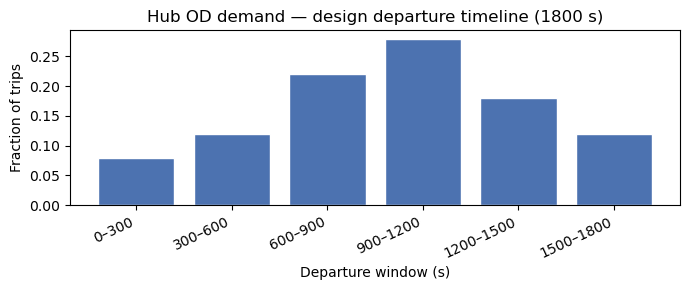

In [19]:
# Demand timeline (design weights) — visual reference for Section 3
import json
import matplotlib.pyplot as plt
from pathlib import Path

manifest = json.loads((Path('..') / 'data/raw_data/grid4x4/od_hubs/demand_set/manifest.json').read_text())
bins = manifest['timeline_bins_s']
labels = [f"{int(b)}–{int(e)}" for b, e, _ in bins]
weights = [w for _, _, w in bins]
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(labels, weights, color='#4C72B0', edgecolor='white')
ax.set_ylabel('Fraction of trips')
ax.set_xlabel('Departure window (s)')
ax.set_title('Hub OD demand — design departure timeline (1800 s)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


---

## 6. Results (logs synced from gpujobs)

Tables and curves below use latest `2026_07_25` DTL logs when present.


In [20]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

REPO = Path('..').resolve()
OUT = REPO / 'data' / 'output_data' / 'tsc'
COLS = ['model', 'split', 'episode', 'travel_time', 'col5', 'reward', 'queue', 'delay', 'throughput']

SLURM_ELAPSED = {
    ('DQN', 'L1'): '00:29:24', ('PressLight', 'L1'): '00:27:23', ('CoLight', 'L1'): '00:23:48',
    ('DQN', 'L2'): '00:32:40', ('PressLight', 'L2'): '00:29:25', ('CoLight', 'L2'): '00:30:46',
}


def _logger(agent_folder: str, level_slug: str, prefix: str) -> Path:
    return OUT / agent_folder / 'sumo4x4' / prefix / 'logger'


def build_odh_experiment(level_key: str, level_slug: str, prefix: str, toggle: str) -> dict:
    return {
        'toggle': toggle,
        'level': level_key,
        'rl': {
            'DQN': _logger(f'sumo_dqn_odh_{level_slug}', level_slug, prefix),
            'PressLight': _logger(f'sumo_presslight_odh_{level_slug}', level_slug, prefix),
            'CoLight': _logger(f'sumo_colight_odh_{level_slug}', level_slug, prefix),
        },
        'baselines': {
            'MaxPressure': _logger(f'sumo_maxpressure_odh_{level_slug}', level_slug, prefix),
            'FixedTime': _logger(f'sumo_fixedtime_odh_{level_slug}', level_slug, prefix),
        },
    }


EXPERIMENTS_ODH = {
    'L1': build_odh_experiment('L1', 'l1', 'odh_l1', 'Level 1 — hub OD demand only'),
    'L2': build_odh_experiment('L2', 'l2', 'odh_l2', 'Level 2 — hub OD + realism_full'),
}


def load_dtl(logger_dir: Path):
    best, best_ep, best_path = None, -1, ''
    candidates = sorted(logger_dir.glob('*_DTL.log'))
    server = [p for p in candidates if '2026_07_25' in p.name]
    candidates = server or candidates
    for p in candidates:
        df = pd.read_csv(p, sep='\t', header=None, names=COLS)
        mx = int(df['episode'].max())
        if mx > best_ep or (mx == best_ep and p.name > best_path):
            best, best_ep, best_path = df, mx, p.name
    if best is None:
        raise FileNotFoundError(f'No DTL logs in {logger_dir}')
    return best, logger_dir / best_path


def heldout_series(df: pd.DataFrame) -> pd.DataFrame:
    return df[df.split == 'HELDOUT_MEAN'].sort_values('episode').reset_index(drop=True)


def final_heldout_att(df: pd.DataFrame) -> float:
    ho = heldout_series(df)
    if ho.empty:
        raise ValueError('No HELDOUT_MEAN rows in log')
    return float(ho.travel_time.iloc[-1])


def brf_wall_seconds(logger_dir: Path) -> float | None:
    brfs = sorted(logger_dir.glob('*_BRF.log'))
    brfs = [p for p in brfs if '2026_07_25' in p.name] or brfs
    if not brfs:
        return None
    hits = re.findall(r'Total time taken: ([0-9.]+)', brfs[-1].read_text(errors='ignore'))
    return float(hits[-1]) if hits else None


def make_table(cfg: dict) -> pd.DataFrame:
    rows = []
    for name, path in cfg.get('rl', {}).items():
        df, log_path = load_dtl(path)
        ho = heldout_series(df)
        rows.append({
            'method': name,
            'best_heldout_att': round(ho.travel_time.min(), 2),
            'final_heldout_att': round(ho.travel_time.iloc[-1], 2),
            'ep_max': int(df.episode.max()),
            'log': log_path.name,
        })
    for name, path in cfg.get('baselines', {}).items():
        df, log_path = load_dtl(path)
        att = round(final_heldout_att(df), 2)
        rows.append({
            'method': name,
            'best_heldout_att': att,
            'final_heldout_att': att,
            'ep_max': int(df.episode.max()),
            'log': log_path.name,
        })
    return pd.DataFrame(rows).sort_values('final_heldout_att').reset_index(drop=True)


def make_l2_vs_l1_table() -> pd.DataFrame:
    l1 = make_table(EXPERIMENTS_ODH['L1']).set_index('method')
    l2 = make_table(EXPERIMENTS_ODH['L2']).set_index('method')
    rows = []
    for method in l2.index:
        rows.append({
            'method': method,
            'L1_heldout_att': l1.loc[method, 'final_heldout_att'] if method in l1.index else None,
            'L2_heldout_att': l2.loc[method, 'final_heldout_att'],
            'delta_L2_minus_L1': round(l2.loc[method, 'final_heldout_att'] - l1.loc[method, 'final_heldout_att'], 2)
            if method in l1.index else None,
            'log_L2': l2.loc[method, 'log'],
        })
    return pd.DataFrame(rows).sort_values('L2_heldout_att').reset_index(drop=True)


def load_level_rl(cfg: dict) -> dict:
    out = {}
    for name, path in cfg['rl'].items():
        df, log_path = load_dtl(path)
        out[name] = {
            'train': df[df.split == 'TRAIN'].reset_index(drop=True),
            'heldout': heldout_series(df),
            'log': log_path,
        }
    return out


def plot_rl_curves(rl_data: dict, title: str):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    for ax, name in zip(axes, ['DQN', 'PressLight', 'CoLight']):
        tr = rl_data[name]['train']
        ho = rl_data[name]['heldout']
        ho_plot = ho[ho.episode >= 10] if (ho.episode >= 10).any() else ho
        if len(tr):
            ax.plot(tr.episode, tr.travel_time, color='#4C72B0', linestyle='--', alpha=0.8, label='train file')
        ax.plot(ho_plot.episode, ho_plot.travel_time, color='#C44E52', marker='o', ms=3, lw=1.8, label='held-out mean')
        ax.set_title(name)
        ax.set_xlabel('episode')
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('ATT (s)')
    axes[-1].legend(loc='upper right', fontsize=9)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def rl_runtime_table() -> pd.DataFrame:
    rows = []
    for level_key, cfg in EXPERIMENTS_ODH.items():
        for name, path in cfg['rl'].items():
            wall = brf_wall_seconds(path)
            rows.append({
                'level': level_key,
                'method': name,
                'libsignal_wall_s': round(wall, 1) if wall else None,
                'slurm_elapsed': SLURM_ELAPSED.get((name, level_key)),
                'log': load_dtl(path)[1].name,
            })
    return pd.DataFrame(rows)


## 6.1 Level 1 — demand only

Primary score: **final held-out ATT** (`HELDOUT_MEAN` at last eval). RL also shows **best** held-out checkpoint over training.


In [21]:
table_l1 = make_table(EXPERIMENTS_ODH['L1'])
table_l1


,method,best_heldout_att,final_heldout_att,ep_max,log
0,DQN,156.8,156.9,100,2026_07_25-03_08_21_DTL.log
1,MaxPressure,157.2,157.2,1,2026_07_25-03_08_00_DTL.log
2,CoLight,156.3,157.5,100,2026_07_25-03_24_43_DTL.log
3,PressLight,162.3,163.4,100,2026_07_25-03_08_21_DTL.log
4,FixedTime,186.6,186.6,1,2026_07_25-03_08_00_DTL.log


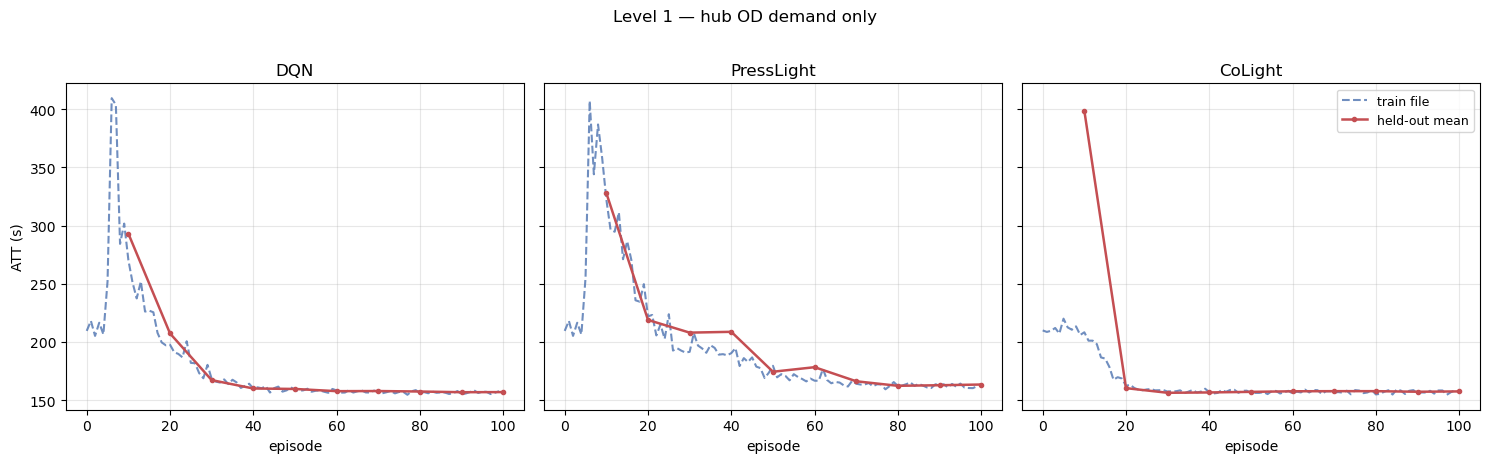

In [14]:
l1_rl = load_level_rl(EXPERIMENTS_ODH['L1'])
plot_rl_curves(l1_rl, EXPERIMENTS_ODH['L1']['toggle'])


## 6.2 Level 2 — demand + realism_full

Same table layout as realism capstone runs: final held-out ATT and shift vs L1.


In [15]:
table_l2 = make_table(EXPERIMENTS_ODH['L2'])
table_l2


,method,best_heldout_att,final_heldout_att,ep_max,log
0,MaxPressure,186.9,186.9,1,2026_07_25-03_24_43_DTL.log
1,PressLight,187.9,190.9,100,2026_07_25-04_40_03_DTL.log
2,FixedTime,192.2,192.2,1,2026_07_25-03_25_08_DTL.log
3,DQN,236.0,245.3,100,2026_07_25-04_40_03_DTL.log
4,CoLight,305.4,436.4,100,2026_07_25-04_40_03_DTL.log


In [16]:
capstone_table = make_l2_vs_l1_table()
capstone_table


,method,L1_heldout_att,L2_heldout_att,delta_L2_minus_L1,log_L2
0,MaxPressure,157.2,186.9,29.7,2026_07_25-03_24_43_DTL.log
1,PressLight,163.4,190.9,27.5,2026_07_25-04_40_03_DTL.log
2,FixedTime,186.6,192.2,5.6,2026_07_25-03_25_08_DTL.log
3,DQN,156.9,245.3,88.4,2026_07_25-04_40_03_DTL.log
4,CoLight,157.5,436.4,278.9,2026_07_25-04_40_03_DTL.log


## 6.3 Interpretation — ranking vs axis studies — ranking vs axis studies

**Observation (this batch, grid4×4, seed 42):** method **ranking is largely preserved** vs the earlier realism axis work:

- **MaxPressure** stays best or near-best on held-out ATT (L1 and L2).
- **PressLight** tracks below MP; **DQN** mid-pack; **CoLight** struggles under stress — same qualitative ordering as `realism_full` / homo capstone tables.
- **L2** raises ATT for everyone (demand + compound plant/sensor) but does **not** reorder the leaderboard into “RL clearly wins.”

**How we phrase the contribution (honest):**

1. **Protocol:** held-out hub-centric demand is a **fairer** RL-TSC comparison than one training movie — even when rankings stay similar.
2. **Demand realism (L1):** tests **generalization** across OD draws; MP remains strong — aligns with “classical baseline is hard to beat.”
3. **Full stack (L2):** same story under **demand + realism_full** — consistent with axis studies, not a new SOTA agent story.
4. **Open question:** **other networks** (e.g. 7×28), longer horizon, more hold files, or multi-seed — ranking might shift; grid4×4 is a **first** capstone, not the final word.

> **Highlight:** We are **adding** demand realism **on top of** the realism axes we already built — not replacing them. L1 isolates demand; L2 is the **full deployment-shaped** profile. Similar rankings suggest the stress test is **working** (hard scenario, MP anchor) rather than that demand realism “does nothing.”


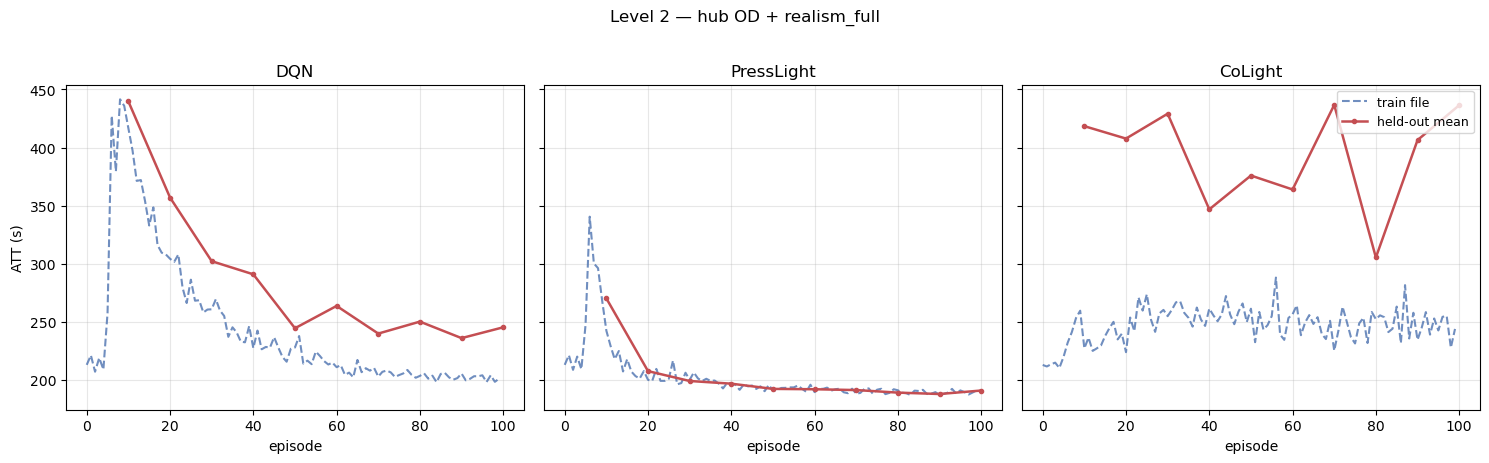

In [17]:
l2_rl = load_level_rl(EXPERIMENTS_ODH['L2'])
plot_rl_curves(l2_rl, EXPERIMENTS_ODH['L2']['toggle'])


### Reading the capstone table

- **L1:** whether RL closes the gap to **MaxPressure** under hub OD generalization (held-out, not the training movie).
- **L2:** compound plant + sensor stress on top of demand realism — expect higher ATT; check if **MP stays the anchor**.

## 6.3 RL training wall time (gpujobs, seed 42)

LibSignal `Total time taken` from BRF (100 episodes) and SLURM elapsed for the three RL methods.


In [18]:
runtime_table = rl_runtime_table()
runtime_table


,level,method,libsignal_wall_s,slurm_elapsed,log
0,L1,DQN,1759.0,00:29:24,2026_07_25-03_08_21_DTL.log
1,L1,PressLight,1638.5,00:27:23,2026_07_25-03_08_21_DTL.log
2,L1,CoLight,1422.5,00:23:48,2026_07_25-03_24_43_DTL.log
3,L2,DQN,1954.2,00:32:40,2026_07_25-04_40_03_DTL.log
4,L2,PressLight,1759.1,00:29:25,2026_07_25-04_40_03_DTL.log
5,L2,CoLight,1840.9,00:30:46,2026_07_25-04_40_03_DTL.log
